<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/14_SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Singular Value Decomposition (SVD)**

This notebook covers Singular Value Decomposition (SVD):
1. Understanding SVD
2. Low-Rank Approximation
3. Relationship to Eigendecomposition
4. Summary


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

## **1. Understanding SVD**

For any m×n matrix A, the Singular Value Decomposition is:

A = U Σ V^T

where:
- U: m×m orthogonal matrix (left singular vectors)
- Σ: m×n diagonal matrix (singular values on diagonal)
- V^T: n×n orthogonal matrix transpose (right singular vectors)

The singular values σ₁ ≥ σ₂ ≥ ... ≥ σᵣ > 0 satisfy important properties:
- The number of non-zero singular values equals the rank of A
- Singular values measure the 'importance' of corresponding dimensions
- σᵢ² are eigenvalues of both AA^T and A^T A

In [2]:
# Create a simple matrix
A = np.array([[3, 2, 2],
              [2, 3, -2]], dtype=float)

print('SINGULAR VALUE DECOMPOSITION')
print('=' * 70)
print(f'Matrix A (2x3):')
print(A)
print(f'Shape: {A.shape}')

# Compute SVD
U, singular_values, Vt = np.linalg.svd(A, full_matrices=True)

print(f'\nU (left singular vectors, 2x2):')
print(U)

print(f'\nSingular values: {singular_values}')

print(f'\nV^T (right singular vectors, 3x3):')
print(Vt)

# Reconstruct
Sigma = np.zeros((A.shape[0], A.shape[1]))
Sigma[:len(singular_values), :len(singular_values)] = np.diag(singular_values)

A_reconstructed = U @ Sigma @ Vt
print(f'\nReconstructed A = U Σ V^T:')
print(A_reconstructed)
print(f'\nMatches original: {np.allclose(A, A_reconstructed)}')

SINGULAR VALUE DECOMPOSITION
Matrix A (2x3):
[[ 3.  2.  2.]
 [ 2.  3. -2.]]
Shape: (2, 3)

U (left singular vectors, 2x2):
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]

Singular values: [5. 3.]

V^T (right singular vectors, 3x3):
[[-7.07106781e-01 -7.07106781e-01 -6.47932334e-17]
 [-2.35702260e-01  2.35702260e-01 -9.42809042e-01]
 [-6.66666667e-01  6.66666667e-01  3.33333333e-01]]

Reconstructed A = U Σ V^T:
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

Matches original: True


## **2. Low-Rank Approximation and Image Compression**

### **Truncated SVD**

The key power of SVD is the ability to create low-rank approximations:

A_k = U_k Σ_k V_k^T

where we keep only the first k singular values and corresponding singular vectors. This approximation has rank k and captures the k most important directions in the data.

### **Application: Image Compression**

Images are matrices of pixel values. Low-rank SVD approximation compresses images by keeping only the most important singular values, dramatically reducing storage while maintaining visual quality.

IMAGE COMPRESSION USING SVD
Image shape: (100, 100)
Number of singular values: 100
k=  5: compression ratio=10.05%, relative error=0.3630
k= 10: compression ratio=20.10%, relative error=0.3256
k= 20: compression ratio=40.20%, relative error=0.2607
k= 50: compression ratio=100.50%, relative error=0.1129
k=100: compression ratio=201.00%, relative error=0.0000


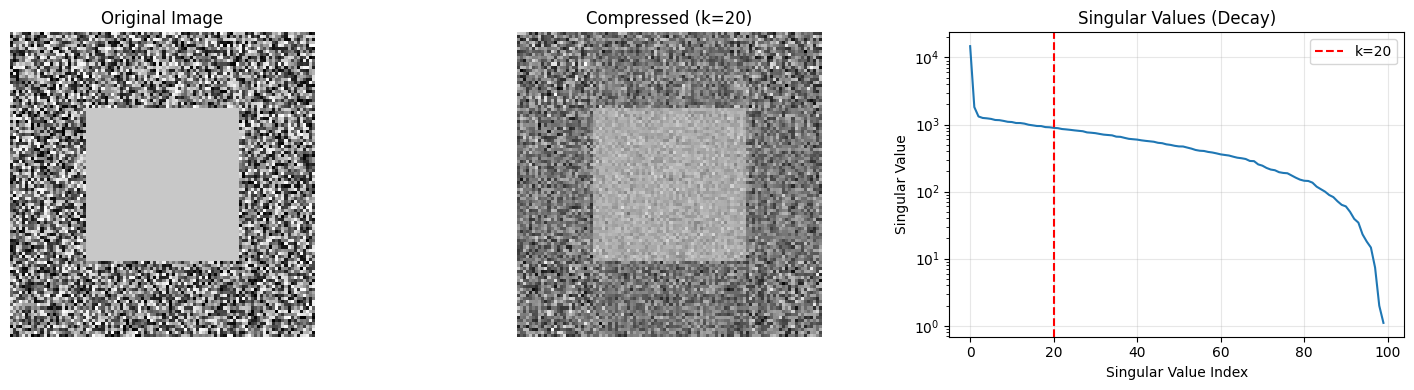

In [3]:
# Create a synthetic image (2D array)
image = np.random.rand(100, 100) * 255
image[25:75, 25:75] = 200  # Add a square region

print('IMAGE COMPRESSION USING SVD')
print('=' * 70)

# Compute SVD
U, s, Vt = np.linalg.svd(image, full_matrices=False)

print(f'Image shape: {image.shape}')
print(f'Number of singular values: {len(s)}')

# Compression ratios
compression_ratios = []
reconstruction_errors = []
k_values = [5, 10, 20, 50, 100]

for k in k_values:
    # Truncated SVD
    U_k = U[:, :k]
    s_k = s[:k]
    Vt_k = Vt[:k, :]

    image_k = U_k @ np.diag(s_k) @ Vt_k

    # Compression ratio
    original_size = image.shape[0] * image.shape[1]
    compressed_size = k * (image.shape[0] + image.shape[1] + 1)
    ratio = compressed_size / original_size
    compression_ratios.append(ratio)

    # Reconstruction error
    error = np.linalg.norm(image - image_k, 'fro') / np.linalg.norm(image, 'fro')
    reconstruction_errors.append(error)

    print(f'k={k:3d}: compression ratio={ratio:.2%}, relative error={error:.4f}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

k_show = 20
U_k = U[:, :k_show]
s_k = s[:k_show]
Vt_k = Vt[:k_show, :]
image_compressed = U_k @ np.diag(s_k) @ Vt_k

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(image_compressed, cmap='gray')
axes[1].set_title(f'Compressed (k={k_show})')
axes[1].axis('off')

axes[2].semilogy(s)
axes[2].axvline(x=k_show, color='r', linestyle='--', label=f'k={k_show}')
axes[2].set_xlabel('Singular Value Index')
axes[2].set_ylabel('Singular Value')
axes[2].set_title('Singular Values (Decay)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **3. Relationship to Eigendecomposition**

### **Connection**

SVD and eigendecomposition are intimately related:

If A = U Σ V^T, then:
- AA^T = U Σ^2 U^T (eigendecomposition of AA^T)
- A^T A = V Σ^2 V^T (eigendecomposition of A^T A)

The singular values σᵢ of A are the square roots of the eigenvalues of AA^T and A^T A.
The columns of U are eigenvectors of AA^T.
The columns of V are eigenvectors of A^T A.

This relationship explains why SVD is so powerful: it gives us a unified framework for understanding rectangular matrices through the eigendecompositions of their Gram matrices.

In [4]:
print('RELATIONSHIP BETWEEN SVD AND EIGENDECOMPOSITION')
print('=' * 70)

# Use previous matrix A
print(f'Matrix A:')
print(A)

# SVD
U, s, Vt = np.linalg.svd(A, full_matrices=True)

# Eigendecomposition of A A^T
AAT = A @ A.T
evals_AAT, evecs_AAT = np.linalg.eig(AAT)
idx = evals_AAT.argsort()[::-1]
evals_AAT = evals_AAT[idx]
evecs_AAT = evecs_AAT[:, idx]

print(f'\nEigenvalues of AA^T: {evals_AAT}')
print(f'Singular values (squared): {s**2}')
print(f'√(eigenvalues of AA^T): {np.sqrt(np.maximum(evals_AAT, 0))}')

# Eigendecomposition of A^T A
ATA = A.T @ A
evals_ATA, evecs_ATA = np.linalg.eig(ATA)
idx = evals_ATA.argsort()[::-1]
evals_ATA = evals_ATA[idx]
evecs_ATA = evecs_ATA[:, idx]

print(f'\nEigenvalues of A^T A: {evals_ATA}')
print(f'√(eigenvalues of A^T A): {np.sqrt(np.maximum(evals_ATA, 0))}')

print(f'\nU (from SVD) matches eigenvectors of AA^T: {np.allclose(np.abs(U), np.abs(evecs_AAT))}')
print(f'V (from SVD) matches eigenvectors of A^T A: {np.allclose(np.abs(Vt.T), np.abs(evecs_ATA))}')

RELATIONSHIP BETWEEN SVD AND EIGENDECOMPOSITION
Matrix A:
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

Eigenvalues of AA^T: [25.  9.]
Singular values (squared): [25.  9.]
√(eigenvalues of AA^T): [5. 3.]

Eigenvalues of A^T A: [2.5000000e+01 9.0000000e+00 5.0324328e-15]
√(eigenvalues of A^T A): [5.0000000e+00 3.0000000e+00 7.0939642e-08]

U (from SVD) matches eigenvectors of AA^T: True
V (from SVD) matches eigenvectors of A^T A: True


## **4. Summary**

SVD is the most fundamental matrix decomposition:

**Fundamental Decomposition**: A = U Σ V^T decomposes any matrix into orthogonal matrices (U, V) and singular values (Σ), working for rectangular or square matrices.

**Low-Rank Approximation**: Truncated SVD creates rank-k approximations that capture the k most important dimensions, essential for compression and dimensionality reduction.

**Image Compression**: SVD enables efficient image compression by keeping only the most significant singular values, reducing storage while maintaining visual quality.

**Connection to Eigendecomposition**: SVD is intimately related to eigendecomposition of Gram matrices (AA^T and A^T A), providing a unified framework for rectangular matrices.

SVD appears throughout data science in PCA, recommendation systems, image processing, and numerous applications. Its universality makes it indispensable for modern data analysis.